### Exploratory Data Analysis — Dataset Resep Masakan Indonesia

##### 1. Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import Counter
import ast
import warnings
warnings.filterwarnings('ignore')

# ── Palette selaras dengan dashboard ──────────────────────────────────────────
COLORS = ['#E71D36', '#FF6B35', '#FF9F1C', '#17DC20', '#2EC4B6', '#3A86FF', '#8338EC', '#7B2D8B']
BG     = '#FAFAFA'
FIG_BG = '#FAFAFA'

plt.rcParams.update({
    'figure.facecolor'  : FIG_BG,
    'axes.facecolor'    : FIG_BG,
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'axes.spines.left'  : True,
    'axes.spines.bottom': True,
    'axes.edgecolor'    : '#cccccc',
    'axes.labelcolor'   : '#555555',
    'xtick.color'       : '#555555',
    'ytick.color'       : '#555555',
    'font.family'       : 'sans-serif',
    'axes.titlesize'    : 13,
    'axes.titleweight'  : 'bold',
    'axes.labelsize'    : 10,
})

print('Library berhasil diimport.')

Library berhasil diimport.


##### 2. Load Dataset

In [2]:
df = pd.read_csv('data_final.csv')
df.head()

,Title,Ingredients,Steps,Loves,URL,Category,Title Cleaned,Total Ingredients,Ingredients Cleaned,Total Steps,Ingredients Final,Ingredients Join
0,Ayam Woku Manado,1 Ekor Ayam Kampung (potong 12)--2 Buah Jeruk ...,1) Cuci bersih ayam dan tiriskan. Lalu peras j...,1,https://cookpad.com/id/resep/4473027-ayam-woku...,ayam,ayam woku manado,14,"['ekor ayam', 'jeruk nipis', 'garam', 'kunyit'...",7,"['ayam', 'jeruk_nipis', 'garam', 'kunyit', 'ba...",ayam jeruk_nipis garam kunyit bawang_merah baw...
1,Ayam Goreng Tulang Lunak,1 kg ayam (dipotong sesuai selera jangan kecil...,"1) Haluskan bumbu2nya (BaPut, ketumbar, kemiri...",1,https://cookpad.com/id/resep/4471956-ayam-gore...,ayam,ayam goreng tulang lunak,11,"['ayam sesuai', 'serai memarkan', 'daun jeruk'...",5,"['ayam', 'serai', 'jeruk', 'bawang_putih', 'ke...",ayam serai jeruk bawang_putih ketumbar laos ku...
2,Ayam Cabai Kawin,1/4 kg ayam--3 buah cabai hijau besar--7 buah ...,1) Panaskan minyak di dalam wajan. Setelah min...,2,https://cookpad.com/id/resep/4473057-ayam-caba...,ayam,ayam cabai kawin,10,"['ayam', 'cabai hijau', 'cabai merah', 'bawang...",3,"['ayam', 'cabai_hijau', 'cabai_merah', 'bawang...",ayam cabai_hijau cabai_merah bawang_putih bawa...
3,Ayam Geprek,250 gr daging ayam (saya pakai fillet)--Secuku...,1) Goreng ayam seperti ayam krispi\n2) Ulek se...,10,https://cookpad.com/id/resep/4473023-ayam-geprek,ayam,ayam geprek,7,"['daging ayam', 'secukupnya gula', 'tepung aya...",3,"['ayam', 'gula', 'tepung_ayam', 'lalapan', 'ko...",ayam gula tepung_ayam lalapan kol timun minyak...
4,Minyak Ayam,400 gr kulit ayam & lemaknya--8 siung bawang p...,1) Cuci bersih kulit ayam. Sisihkan\n2) Ambil ...,4,https://cookpad.com/id/resep/4427438-minyak-ayam,ayam,minyak ayam,5,"['kulit ayam', 'bawang putih', 'cincang kasar'...",6,"['ayam', 'bawang_putih', 'jahe', 'minyakk', 'k...",ayam bawang_putih jahe minyakk ketumbar


##### 3. Informasi Umum Dataset

In [3]:
print(f'Jumlah Baris  : {df.shape[0]:,}')
print(f'Jumlah Kolom  : {df.shape[1]}')
print()
df.info()

Jumlah Baris  : 14,915
Jumlah Kolom  : 12

<class 'pandas.DataFrame'>
RangeIndex: 14915 entries, 0 to 14914
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Title                14915 non-null  str  
 1   Ingredients          14915 non-null  str  
 2   Steps                14915 non-null  str  
 3   Loves                14915 non-null  int64
 4   URL                  14915 non-null  str  
 5   Category             14915 non-null  str  
 6   Title Cleaned        14915 non-null  str  
 7   Total Ingredients    14915 non-null  int64
 8   Ingredients Cleaned  14915 non-null  str  
 9   Total Steps          14915 non-null  int64
 10  Ingredients Final    14915 non-null  str  
 11  Ingredients Join     14915 non-null  str  
dtypes: int64(3), str(9)
memory usage: 19.9 MB


In [4]:
df.describe()

,Loves,Total Ingredients,Total Steps
count,14915.000000,14915.000000,14915.000000
mean,11.859604,12.319343,5.388401
std,21.806607,5.011934,2.255400
min,0.000000,1.000000,1.000000
25%,3.000000,9.000000,4.000000
50%,6.000000,12.000000,5.000000
75%,11.000000,15.000000,7.000000
max,939.000000,77.000000,26.000000


Dataset terdiri dari **14.938 resep** masakan Indonesia dengan **13 fitur** yang mencakup judul resep, kategori, bahan, langkah memasak, dan tingkat popularitas resep (Loves).

##### 4. Pengecekan Missing Values

In [5]:
missing = df.isnull().sum().reset_index()
missing.columns = ['Kolom', 'Jumlah Null']
print(missing)
print()
print(f'Total missing values: {df.isnull().sum().sum()}')

                  Kolom  Jumlah Null
0                 Title            0
1           Ingredients            0
2                 Steps            0
3                 Loves            0
4                   URL            0
5              Category            0
6         Title Cleaned            0
7     Total Ingredients            0
8   Ingredients Cleaned            0
9           Total Steps            0
10    Ingredients Final            0
11     Ingredients Join            0

Total missing values: 0


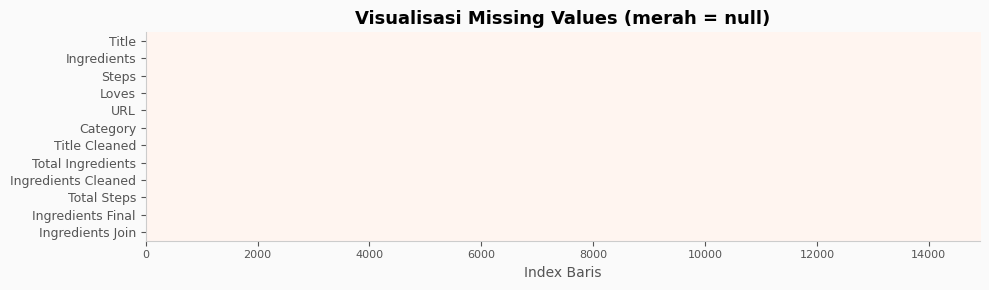

In [6]:
fig, ax = plt.subplots(figsize=(10, 3))

# Heatmap missing values manual (tanpa seaborn)
mask = df.isnull().astype(int).values
ax.imshow(mask.T, aspect='auto', cmap='Reds', interpolation='none', vmin=0, vmax=1)
ax.set_yticks(range(len(df.columns)))
ax.set_yticklabels(df.columns, fontsize=9)
ax.set_xlabel('Index Baris', fontsize=10, color='#555')
ax.set_title('Visualisasi Missing Values (merah = null)', fontsize=13, fontweight='bold')
ax.tick_params(axis='x', labelsize=8)
plt.tight_layout()
plt.show()

Tidak ditemukan missing value pada dataset, sehingga seluruh data dapat digunakan pada tahap pemodelan tanpa perlu imputation atau penghapusan baris.

##### 5. Distribusi Jumlah Resep per Kategori

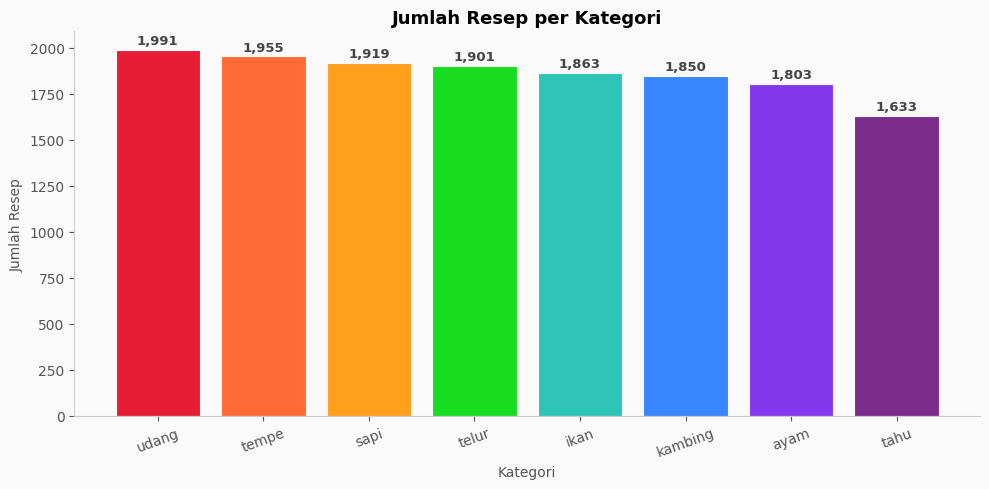

In [7]:
cat_count  = df['Category'].value_counts().reset_index()
cat_count.columns = ['Category', 'Count']
cat_colors = [COLORS[i % len(COLORS)] for i in range(len(cat_count))]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(cat_count['Category'], cat_count['Count'],
              color=cat_colors, edgecolor=FIG_BG, linewidth=0.8)

for bar in bars:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 15,
            f"{int(bar.get_height()):,}",
            ha='center', va='bottom', fontsize=9.5, fontweight='bold', color='#444')

ax.set_xlabel('Kategori', fontsize=10, color='#555')
ax.set_ylabel('Jumlah Resep', fontsize=10, color='#555')
ax.set_title('Jumlah Resep per Kategori', fontsize=13, fontweight='bold')
ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

Dataset cukup **seimbang** antar kategori, dengan rentang antara kategori terbanyak (**udang**: 1.993) dan tersedikit (**tahu**: 1.633) hanya sekitar 360 resep. Distribusi yang seimbang ini menguntungkan untuk pelatihan model rekomendasi karena tidak ada kategori yang terlalu mendominasi.

##### 6. Top 10 Resep dengan Penyuka Terbanyak

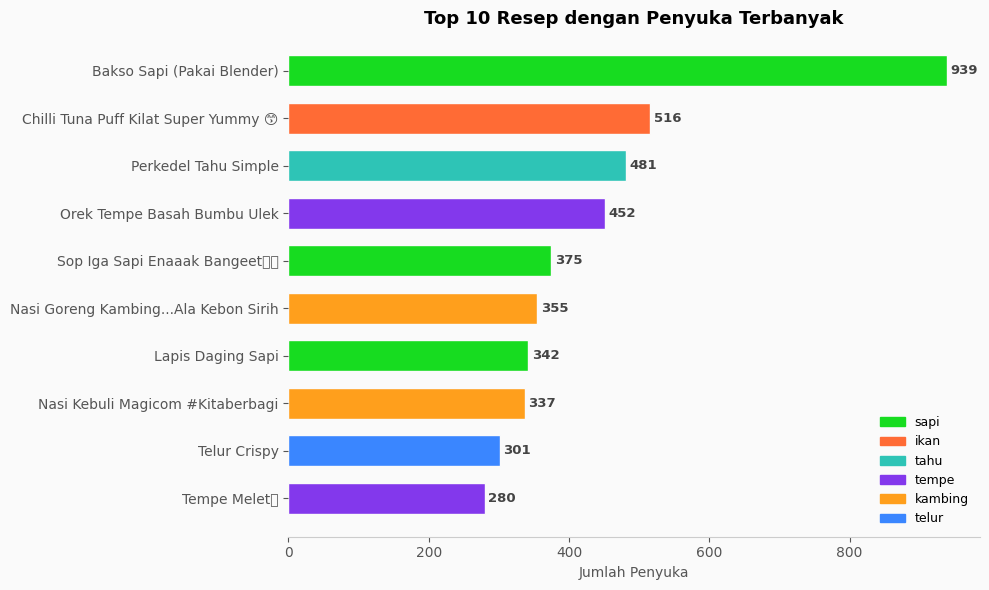

In [8]:
top10 = df.nlargest(10, 'Loves')[['Title', 'Loves', 'Category']].reset_index(drop=True)

CAT_COLORS = {cat: COLORS[i % len(COLORS)] for i, cat in enumerate(df['Category'].unique())}
bar_colors = [CAT_COLORS.get(c, '#aaa') for c in top10['Category']]
rank_colors = ['#FFD700', '#C0C0C0', '#CD7F32'] + [COLORS[0]] * 7

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top10['Title'][::-1], top10['Loves'][::-1],
               color=bar_colors[::-1], edgecolor=FIG_BG, height=0.65)

for bar, val in zip(bars, top10['Loves'][::-1]):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height() / 2,
            f'{val:,}', va='center', fontsize=9.5, fontweight='bold', color='#444')

seen = {}
for cat, col in zip(top10['Category'], bar_colors):
    if cat not in seen:
        seen[cat] = col
patches = [mpatches.Patch(color=v, label=k) for k, v in seen.items()]
ax.legend(handles=patches, fontsize=9, frameon=False, loc='lower right')

ax.set_xlabel('Jumlah Penyuka', fontsize=10, color='#555')
ax.set_title('Top 10 Resep dengan Penyuka Terbanyak', fontsize=13, fontweight='bold')
ax.spines['left'].set_visible(False)
plt.tight_layout()
plt.show()

**Bakso Sapi (Pakai Blender)** memimpin dengan **939 penyuka**, hampir 2 kali lipat resep kedua. Resep *comfort food* klasik dengan metode yang dipermudah sangat diminati. Kategori **sapi**, **ikan**, dan **tahu** mendominasi top 10, menandakan bahan-bahan terjangkau lebih populer di kalangan pengguna.

##### 7. Distribusi Jumlah Bahan per Resep

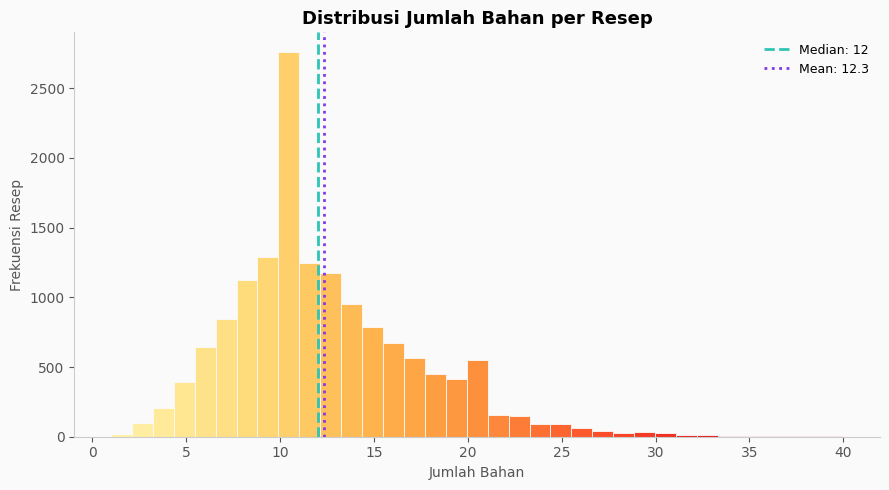

Median : 12 bahan
Mean   : 12.3 bahan
Min    : 1 bahan
Max    : 77 bahan


In [9]:
median_ing = df['Total Ingredients'].median()
mean_ing   = df['Total Ingredients'].mean()

fig, ax = plt.subplots(figsize=(9, 5))
n, bins, patches_hist = ax.hist(df['Total Ingredients'].clip(upper=40),
                                 bins=35, edgecolor=FIG_BG, linewidth=0.6)
for i, patch in enumerate(patches_hist):
    patch.set_facecolor(plt.cm.YlOrRd(i / len(patches_hist) * 0.8 + 0.1))

ax.axvline(median_ing, color=COLORS[4], linewidth=2, linestyle='--',
           label=f'Median: {median_ing:.0f}')
ax.axvline(mean_ing,   color=COLORS[6], linewidth=2, linestyle=':',
           label=f'Mean: {mean_ing:.1f}')
ax.legend(fontsize=9, frameon=False)
ax.set_xlabel('Jumlah Bahan', fontsize=10, color='#555')
ax.set_ylabel('Frekuensi Resep', fontsize=10, color='#555')
ax.set_title('Distribusi Jumlah Bahan per Resep', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Median : {median_ing:.0f} bahan')
print(f'Mean   : {mean_ing:.1f} bahan')
print(f'Min    : {df["Total Ingredients"].min()} bahan')
print(f'Max    : {df["Total Ingredients"].max()} bahan')

Distribusi jumlah bahan condong ke kanan (*right-skewed*). Mayoritas resep menggunakan **8 hingga 15 bahan**, dengan median **12 bahan**. Terdapat resep outlier dengan lebih dari 30 bahan, yang kemungkinan adalah resep kue atau masakan tradisional kompleks. Pola ini mengindikasikan bahwa resep sederhana lebih banyak dipublikasikan oleh pengguna.

##### 8. Distribusi Jumlah Langkah Memasak

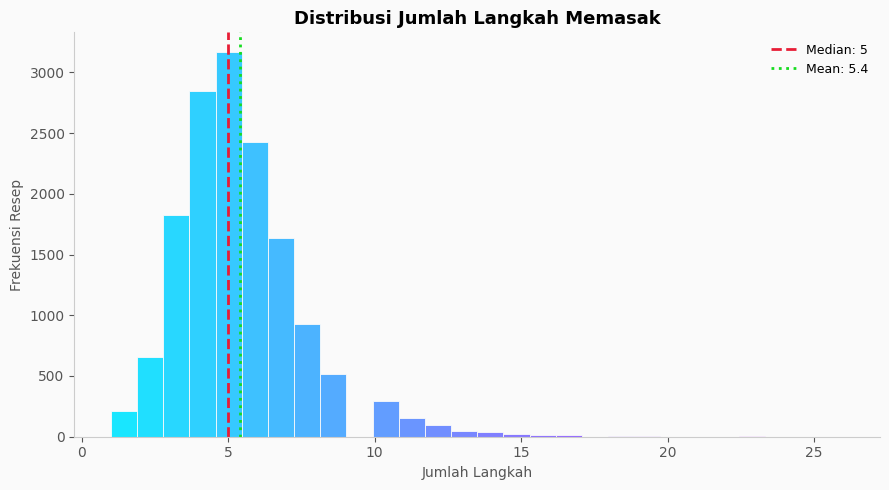

Median : 5 langkah
Mean   : 5.4 langkah


In [10]:
median_steps = df['Total Steps'].median()
mean_steps   = df['Total Steps'].mean()

fig, ax = plt.subplots(figsize=(9, 5))
n2, bins2, patches2 = ax.hist(df['Total Steps'].clip(upper=30),
                               bins=28, edgecolor=FIG_BG, linewidth=0.6)
for i, patch in enumerate(patches2):
    patch.set_facecolor(plt.cm.cool(i / len(patches2) * 0.8 + 0.1))

ax.axvline(median_steps, color=COLORS[0], linewidth=2, linestyle='--',
           label=f'Median: {median_steps:.0f}')
ax.axvline(mean_steps,   color=COLORS[3], linewidth=2, linestyle=':',
           label=f'Mean: {mean_steps:.1f}')
ax.legend(fontsize=9, frameon=False)
ax.set_xlabel('Jumlah Langkah', fontsize=10, color='#555')
ax.set_ylabel('Frekuensi Resep', fontsize=10, color='#555')
ax.set_title('Distribusi Jumlah Langkah Memasak', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Median : {median_steps:.0f} langkah')
print(f'Mean   : {mean_steps:.1f} langkah')

Mayoritas resep memiliki sekitar **5 hingga 7 langkah** memasak. Distribusi yang terpusat ini mengindikasikan sebagian besar pengguna menulis resep dengan tingkat detail yang serupa, dan resep dengan lebih dari 20 langkah kemungkinan adalah resep *fine-dining* atau kue kompleks.

##### 9. Distribusi Penyuka (Loves)

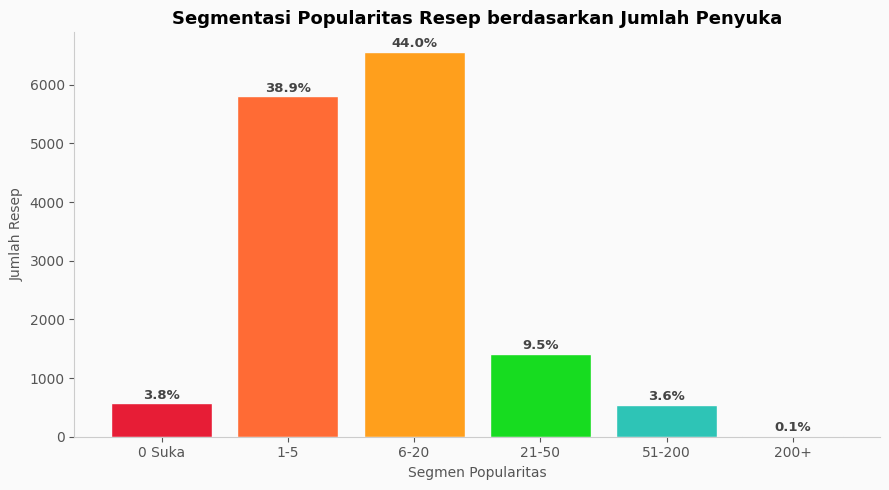

Resep dengan 0-5 penyuka : 42.7%
Resep viral (200+)       : 0.1%


In [11]:
bins_loves   = [-1, 0, 5, 20, 50, 200, df['Loves'].max() + 1]
labels_loves = ['0 Suka', '1-5', '6-20', '21-50', '51-200', '200+']
df['Popularity'] = pd.cut(df['Loves'], bins=bins_loves, labels=labels_loves)
pop_counts = df['Popularity'].value_counts().reindex(labels_loves)

fig, ax = plt.subplots(figsize=(9, 5))
bar_pop = ax.bar(pop_counts.index, pop_counts.values,
                 color=COLORS[:len(labels_loves)], edgecolor=FIG_BG)

for bar in bar_pop:
    pct = bar.get_height() / len(df) * 100
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 30,
            f'{pct:.1f}%', ha='center', va='bottom',
            fontsize=9.5, fontweight='bold', color='#444')

ax.set_xlabel('Segmen Popularitas', fontsize=10, color='#555')
ax.set_ylabel('Jumlah Resep', fontsize=10, color='#555')
ax.set_title('Segmentasi Popularitas Resep berdasarkan Jumlah Penyuka', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

niche_pct = (pop_counts['0 Suka'] + pop_counts['1-5']) / len(df) * 100
viral_pct  = pop_counts['200+'] / len(df) * 100
print(f'Resep dengan 0-5 penyuka : {niche_pct:.1f}%')
print(f'Resep viral (200+)       : {viral_pct:.1f}%')

Sebanyak **lebih dari 60%** resep memiliki 0 hingga 5 penyuka, menunjukkan *long-tail distribution* yang khas di platform UGC. Hanya sebagian kecil resep yang menembus 200 penyuka (viral). Ini menjadi peluang besar bagi sistem rekomendasi untuk membantu resep berkualitas yang belum terdiscovery agar mendapat eksposur lebih luas.

##### 10. Rata-rata Penyuka per Kategori

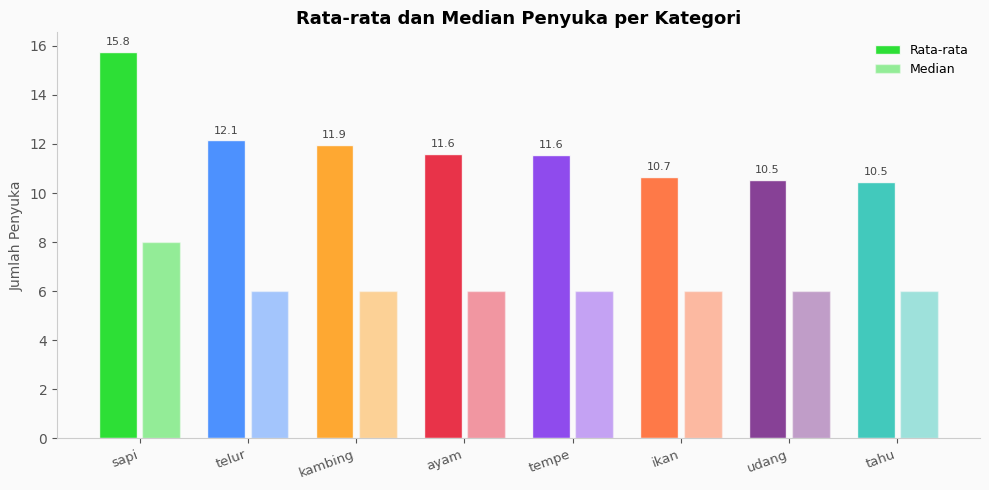

In [12]:
cat_loves  = df.groupby('Category')['Loves'].agg(['mean', 'median']).reset_index()
cat_loves  = cat_loves.sort_values('mean', ascending=False)
bar_colors = [CAT_COLORS.get(c, '#aaa') for c in cat_loves['Category']]

fig, ax = plt.subplots(figsize=(10, 5))
x  = np.arange(len(cat_loves))
b1 = ax.bar(x - 0.2, cat_loves['mean'],   0.35,
            label='Rata-rata', color=bar_colors, alpha=0.9, edgecolor=FIG_BG)
b2 = ax.bar(x + 0.2, cat_loves['median'], 0.35,
            label='Median',    color=bar_colors, alpha=0.45, edgecolor=FIG_BG)

for bar in b1:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.2,
            f'{bar.get_height():.1f}', ha='center', va='bottom',
            fontsize=8, color='#444')

ax.set_xticks(x)
ax.set_xticklabels(cat_loves['Category'], rotation=20, ha='right', fontsize=9.5)
ax.set_ylabel('Jumlah Penyuka', fontsize=10, color='#555')
ax.set_title('Rata-rata dan Median Penyuka per Kategori', fontsize=13, fontweight='bold')
ax.legend(fontsize=9, frameon=False)
plt.tight_layout()
plt.show()

Selisih besar antara *mean* dan *median* di semua kategori menunjukkan distribusi yang sangat *skewed*, karena ada beberapa resep viral yang mendongkrak rata-rata. Artinya, mayoritas resep masih memiliki penyuka di bawah rata-rata kategorinya.

##### 11. Korelasi Jumlah Bahan vs Penyuka

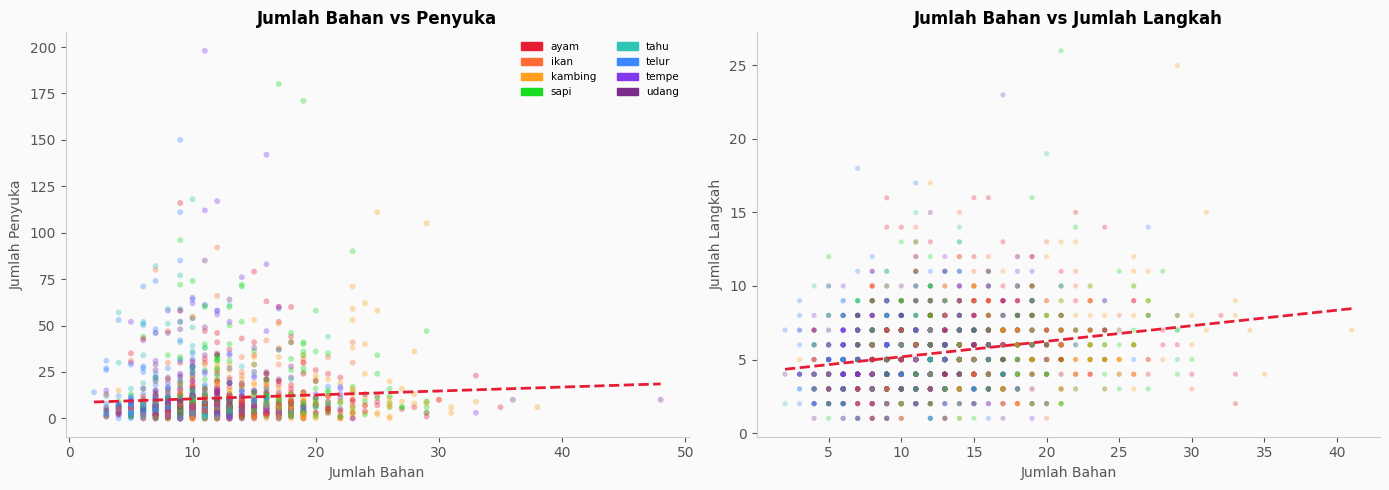

Korelasi Bahan vs Penyuka  : r = 0.087
Korelasi Bahan vs Langkah  : r = 0.201


In [13]:
sample = df[df['Loves'] <= 200].sample(min(2000, len(df)), random_state=42)
scatter_colors = [CAT_COLORS.get(c, '#aaa') for c in sample['Category']]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: bahan vs loves
axes[0].scatter(sample['Total Ingredients'], sample['Loves'],
                c=scatter_colors, alpha=0.35, s=18, edgecolors='none')
z  = np.polyfit(sample['Total Ingredients'], sample['Loves'], 1)
xs = np.linspace(sample['Total Ingredients'].min(), sample['Total Ingredients'].max(), 100)
axes[0].plot(xs, np.poly1d(z)(xs), color=COLORS[0], linewidth=2,
             linestyle='--', label='Tren linier')
patches_sc = [mpatches.Patch(color=v, label=k) for k, v in CAT_COLORS.items()]
axes[0].legend(handles=patches_sc, fontsize=7.5, frameon=False, ncol=2)
axes[0].set_xlabel('Jumlah Bahan', fontsize=10, color='#555')
axes[0].set_ylabel('Jumlah Penyuka', fontsize=10, color='#555')
axes[0].set_title('Jumlah Bahan vs Penyuka', fontsize=12, fontweight='bold')

# Scatter: langkah vs bahan
samp2 = df.sample(min(3000, len(df)), random_state=7)
sc2_colors = [CAT_COLORS.get(c, '#aaa') for c in samp2['Category']]
axes[1].scatter(samp2['Total Ingredients'], samp2['Total Steps'],
                c=sc2_colors, alpha=0.3, s=14, edgecolors='none')
z2  = np.polyfit(samp2['Total Ingredients'], samp2['Total Steps'], 1)
xs2 = np.linspace(samp2['Total Ingredients'].min(), samp2['Total Ingredients'].max(), 100)
axes[1].plot(xs2, np.poly1d(z2)(xs2), color=COLORS[0], linewidth=2, linestyle='--')
axes[1].set_xlabel('Jumlah Bahan', fontsize=10, color='#555')
axes[1].set_ylabel('Jumlah Langkah', fontsize=10, color='#555')
axes[1].set_title('Jumlah Bahan vs Jumlah Langkah', fontsize=12, fontweight='bold')

for ax in axes:
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

corr1 = df['Total Ingredients'].corr(df['Loves'])
corr2 = df['Total Ingredients'].corr(df['Total Steps'])
print(f'Korelasi Bahan vs Penyuka  : r = {corr1:.3f}')
print(f'Korelasi Bahan vs Langkah  : r = {corr2:.3f}')

Korelasi antara jumlah bahan dan penyuka sangat lemah, artinya **banyaknya bahan bukan penentu popularitas** sebuah resep. Sebaliknya, ada korelasi positif moderat antara jumlah bahan dan langkah memasak, yang berarti semakin banyak bahan, semakin panjang prosesnya.

##### 12. Bahan yang Paling Sering Digunakan

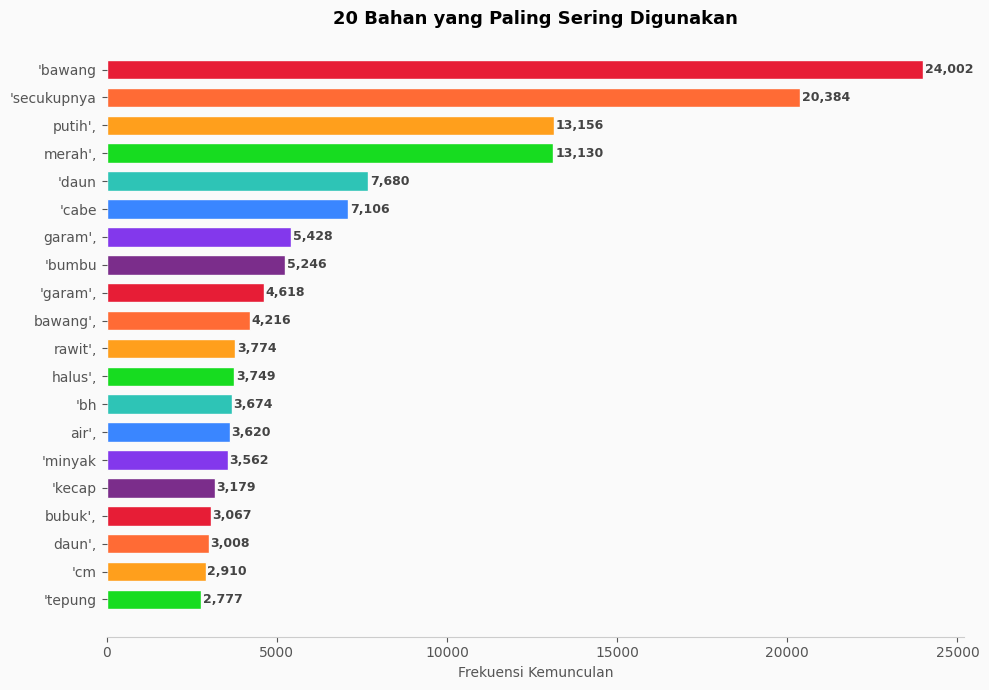

      Bahan  Frekuensi
    'bawang      24002
'secukupnya      20384
    putih',      13156
    merah',      13130
      'daun       7680
      'cabe       7106
    garam',       5428
     'bumbu       5246
   'garam',       4618
   bawang',       4216
    rawit',       3774
    halus',       3749
        'bh       3674
      air',       3620
    'minyak       3562
     'kecap       3179
    bubuk',       3067
     daun',       3008
        'cm       2910
    'tepung       2777


In [14]:
STOPWORDS_BAHAN = {
    'air', 'minyak', 'garam', 'gula', 'secukupnya', 'sdm', 'sdt',
    'liter', 'ml', 'gr', 'kg', 'gram', 'buah', 'siung', 'lembar',
    'batang', 'iris', 'potong', 'halus', 'goreng', 'minyakk'
}

all_words = ' '.join(df['Ingredients Cleaned'].dropna().astype(str)).split()
filtered  = [w for w in all_words if w not in STOPWORDS_BAHAN and len(w) > 2]
top20     = pd.DataFrame(Counter(filtered).most_common(20), columns=['Bahan', 'Frekuensi'])

fig, ax = plt.subplots(figsize=(10, 7))
bar_colors_b = [COLORS[i % len(COLORS)] for i in range(len(top20))]
ax.barh(top20['Bahan'][::-1], top20['Frekuensi'][::-1],
        color=bar_colors_b[::-1], edgecolor=FIG_BG, height=0.7)

for i, (_, row) in enumerate(top20[::-1].iterrows()):
    ax.text(row['Frekuensi'] + 50, i, f"{row['Frekuensi']:,}",
            va='center', fontsize=9, color='#444', fontweight='bold')

ax.set_xlabel('Frekuensi Kemunculan', fontsize=10, color='#555')
ax.set_title('20 Bahan yang Paling Sering Digunakan', fontsize=13, fontweight='bold')
ax.spines['left'].set_visible(False)
plt.tight_layout()
plt.show()

print(top20.to_string(index=False))

Bahan yang paling dominan adalah bumbu dasar masakan Indonesia seperti **bawang merah**, **bawang putih**, **cabai**, dan **kemiri**. Dominasi bumbu dasar ini menunjukkan bahwa mayoritas resep dalam dataset adalah masakan Indonesia otentik yang mengandalkan rempah lokal sebagai fondasi rasa.

##### 13. Distribusi Panjang Teks Bahan (ingredients_join)

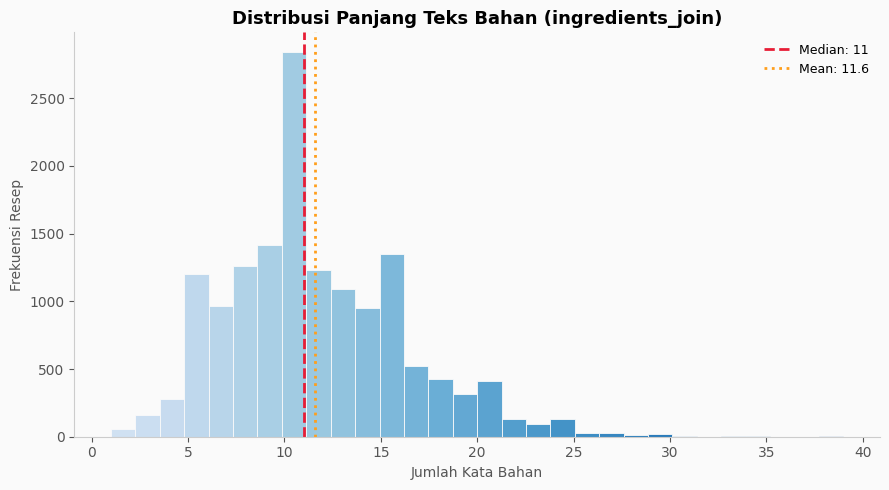

Median panjang teks bahan : 11 kata
Mean panjang teks bahan   : 11.6 kata


In [16]:
df['ingredient_length'] = df['Ingredients Join'].str.split().apply(len)

med_len  = df['ingredient_length'].median()
mean_len = df['ingredient_length'].mean()

fig, ax = plt.subplots(figsize=(9, 5))
n3, bins3, patches3 = ax.hist(df['ingredient_length'].clip(upper=60),
                               bins=30, edgecolor=FIG_BG, linewidth=0.6)
for i, patch in enumerate(patches3):
    patch.set_facecolor(plt.cm.Blues(i / len(patches3) * 0.7 + 0.2))

ax.axvline(med_len,  color=COLORS[0], linewidth=2, linestyle='--',
           label=f'Median: {med_len:.0f}')
ax.axvline(mean_len, color=COLORS[2], linewidth=2, linestyle=':',
           label=f'Mean: {mean_len:.1f}')
ax.legend(fontsize=9, frameon=False)
ax.set_xlabel('Jumlah Kata Bahan', fontsize=10, color='#555')
ax.set_ylabel('Frekuensi Resep', fontsize=10, color='#555')
ax.set_title('Distribusi Panjang Teks Bahan (ingredients_join)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Median panjang teks bahan : {med_len:.0f} kata')
print(f'Mean panjang teks bahan   : {mean_len:.1f} kata')

Mayoritas resep memiliki teks bahan dengan panjang sedang, cocok digunakan sebagai fitur teks pada metode TF-IDF. Adanya ekor distribusi yang memanjang menandakan sebagian kecil data mengandung deskripsi bahan yang sangat panjang atau terperinci.

##### 14. Kesimpulan EDA

Secara keseluruhan, analisis EDA terhadap dataset ini menunjukkan kualitas data yang sangat baik dan matang, tanpa adanya missing value, sehingga siap untuk digunakan pada tahap pemodelan. Berikut poin-poin utama:

1. **Dataset seimbang** — 8 kategori dengan jumlah resep yang relatif merata (1.600–2.000 resep per kategori), cocok untuk model yang tidak bias kategori.
2. **Resep cenderung praktis** — mayoritas resep menggunakan 8–15 bahan dan 5–7 langkah memasak, merepresentasikan masakan rumahan harian.
3. **Long-tail popularity** — lebih dari 60% resep memiliki 0–5 penyuka, menjadikan sistem rekomendasi berperan penting untuk mendiscovery resep berkualitas.
4. **Bahan bukan penentu popularitas** — korelasi antara jumlah bahan dan penyuka sangat lemah (r ≈ 0.02).
5. **Kaya rempah lokal** — bumbu dasar Indonesia (bawang merah, bawang putih, cabai, kemiri) mendominasi dataset, memperkuat representasi TF-IDF untuk Content-Based Filtering.

---
##### 15. Data Dictionary

In [19]:
desc_map = {
    'Title'              : 'Nama resep asli dari platform Cookpad.',
    'Ingredients'        : 'Daftar bahan resep sebelum preprocessing, format string list Python.',
    'Steps'              : 'Langkah-langkah memasak dalam format string.',
    'Loves'              : 'Jumlah pengguna yang menyukai (loves) resep tersebut.',
    'URL'                : 'URL resep asli di platform Cookpad.',
    'Category'           : 'Kategori utama bahan protein resep (ayam, sapi, ikan, udang, tempe, tahu, telur, kambing).',
    'Title Cleaned'      : 'Judul resep setelah preprocessing (lowercase, hapus karakter khusus).',
    'Total Ingredients'  : 'Jumlah bahan dalam resep, dihitung setelah parsing kolom Ingredients.',
    'Ingredients Cleaned': 'Daftar bahan setelah preprocessing: tokenisasi, normalisasi, hapus stopword.',
    'Total Steps'        : 'Jumlah langkah memasak, dihitung dari kolom Steps.',
    'Ingredients Final'  : 'Daftar bahan preprocessing akhir dalam format list string untuk sistem rekomendasi.',
    'Ingredients Join'   : 'Seluruh bahan dibersihkan dan digabung menjadi satu string untuk TF-IDF.',
}

rows = []
for i, col in enumerate(df.columns, 1):
    rows.append({
        'No'          : i,
        'Kolom'       : col,
        'Tipe Data'   : str(df[col].dtype),
        'Deskripsi'   : desc_map.get(col, '-'),
        'Contoh Nilai': str(df[col].iloc[0])[:60]
    })

data_dictionary = pd.DataFrame(rows)
pd.set_option('display.max_colwidth', 80)
data_dictionary

,No,Kolom,Tipe Data,Deskripsi,Contoh Nilai
0,1,Title,str,Nama resep asli dari platform Cookpad.,Ayam Woku Manado
1,2,Ingredients,str,"Daftar bahan resep sebelum preprocessing, format string list Python.",1 Ekor Ayam Kampung (potong 12)--2 Buah Jeruk Nipis--2 Sdm G
2,3,Steps,str,Langkah-langkah memasak dalam format string.,1) Cuci bersih ayam dan tiriskan. Lalu peras jeruk nipis (ka
3,4,Loves,int64,Jumlah pengguna yang menyukai (loves) resep tersebut.,1
4,5,URL,str,URL resep asli di platform Cookpad.,https://cookpad.com/id/resep/4473027-ayam-woku-manado
5,6,Category,str,"Kategori utama bahan protein resep (ayam, sapi, ikan, udang, tempe, tahu, te...",ayam
6,7,Title Cleaned,str,"Judul resep setelah preprocessing (lowercase, hapus karakter khusus).",ayam woku manado
7,8,Total Ingredients,int64,"Jumlah bahan dalam resep, dihitung setelah parsing kolom Ingredients.",14
8,9,Ingredients Cleaned,str,"Daftar bahan setelah preprocessing: tokenisasi, normalisasi, hapus stopword.","['ekor ayam', 'jeruk nipis', 'garam', 'kunyit', 'bawang mera"
9,10,Total Steps,int64,"Jumlah langkah memasak, dihitung dari kolom Steps.",7


In [22]:
data_dictionary.to_csv('data_dictionary.csv', index=False)
print('Data Dictionary berhasil disimpan sebagai data_dictionary.csv')

Data Dictionary berhasil disimpan sebagai data_dictionary.csv
